In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tbforge.lattice import *
from tbforge.plotter import *
from tbforge.hopping import *
from tbforge.hamiltonian import *
from tbforge.solver import *

from _plotstyle import *

## Usage

In [4]:
#1. Create pre-defined lattice
sys = Lattice.honeycomb() #define bulk lattice

#2. Generate hoppings; without hopping radius, NN hopping is assumed
hops = Hopping(sys).find_hops() #assumes order=1 i.e. NN hop by deafult

#2. Build Hamiltonian & add ham terms 
h = Hamiltonian(sys, hops)
h.add_mu(0.)
h.add_nnhops(amp=1.0)

#3. Define the high-symmetry kpath
kpath, kpath_1d, ticks = sys.find_kpath(n_kpts=300)

#4. Pass the Hamiltonian through solver to get bands
bands = Solver(h).get_bands(kpath)

#5. Plot bands using plotter
Plotter().plot_bands(bands, kpath_1d, ticks)

AttributeError: 'tuple' object has no attribute 'get_hops_nn'

We can also plot density of states (DOS)

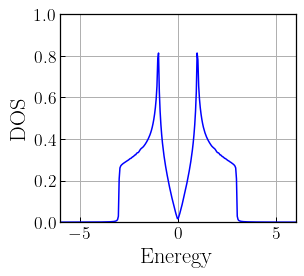

In [59]:
kgrid = lat.find_kgrid(mesh=[300,300,1])
dos = Solver(h).get_dos(kgrid, erange=np.linspace(-6,6,300))
Plotter().plot_dos(dos, ylim=[0,1])

We can also compute bands with other pre-defined lattices:

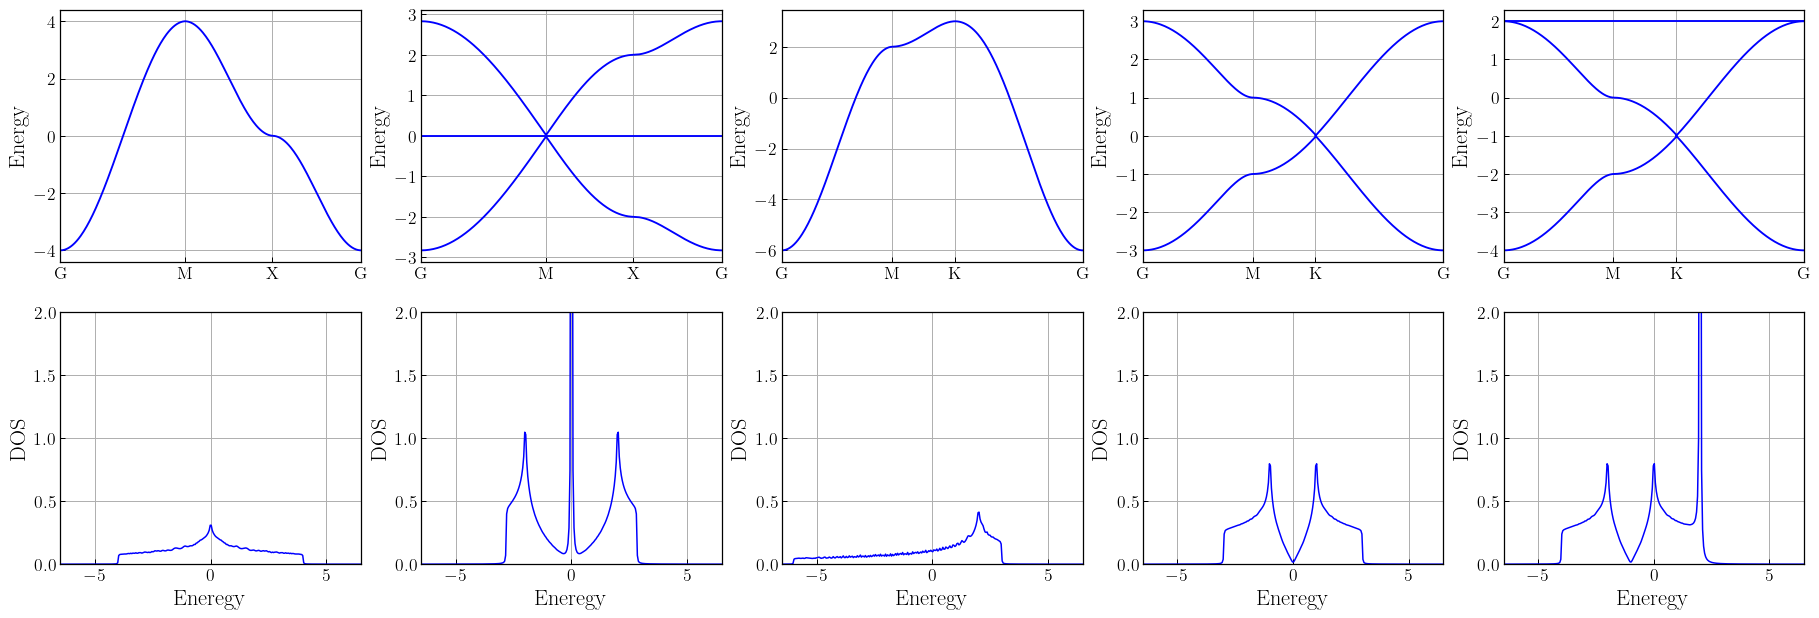

In [60]:
f, axs = plt.subplots(2, 5, figsize=(25,8))

for i, lat in enumerate([Lattice.square(),
                         Lattice.lieb(),
                         Lattice.triangular(),
                         Lattice.honeycomb(),
                         Lattice.kagome()]):
    hops_nn, _ = Hopping().find_hops(lat, order=1)

    h = Hamiltonian(norb=1, nspin=1, nph=1, lat=lat, hops_nn=hops_nn)
    h.add_mu(0.)
    h.add_nnhops(amp=1.0)
    
    #Bands
    kpath, kpath_1d, ticks = lat.find_kpath(n_kpts=300)
    bands = Solver(h).get_bands(kpath)
    Plotter(axs[0,i]).plot_bands(bands, kpath_1d, ticks)

    #DOS
    kgrid = lat.find_kgrid(mesh=[300,300,1])
    dos = Solver(h).get_dos(kgrid, erange=np.linspace(-6.5,6.5,300))
    Plotter(axs[1,i]).plot_dos(dos)

#### NNN hopping

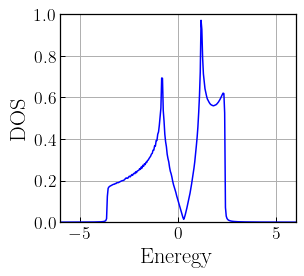

In [68]:
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat, order=1)
hops_2nn, _ = Hopping().find_hops(lat, order=2) #generate NNN hops

h = Hamiltonian(norb=1, nspin=1, nph=1, 
                lat=lat, hops_nn=hops_nn, hops_2nn=hops_2nn) #pass NNN hops into Hamiltonian builder
h.add_mu(0.)
h.add_nnhops(amp=1.0)
h.add_2nnhops(amp=0.1) #add NNN hopping strength

kgrid = lat.find_kgrid(mesh=[300,300,1])
dos = Solver(h).get_dos(kgrid, erange=np.linspace(-6,6,300))
Plotter().plot_dos(dos, ylim=[0,1])

#### Zeeman field

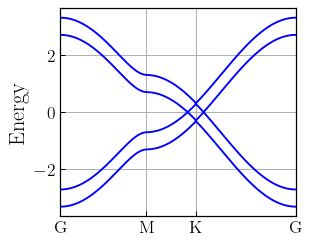

In [62]:
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat, order=1)

h = Hamiltonian(norb=1, nspin=2, nph=1, 
                lat=lat, hops_nn=hops_nn) #here we turn on spin by nspin=2
h.add_mu(0.)
h.add_nnhops(amp=1.0)
h.add_zeeman(0.3) #out-of-plane

kpath, kpath_1d, ticks = lat.find_kpath(n_kpts=300)
bands = Solver(h).get_bands(kpath)
Plotter().plot_bands(bands, kpath_1d, ticks)

#### Rashba SOC

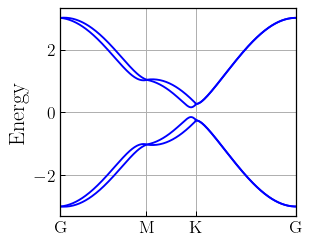

In [63]:
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat, order=1)

h = Hamiltonian(norb=1, nspin=2, nph=1, 
                lat=lat, hops_nn=hops_nn) #here we turn on spin by nspin=2
h.add_mu(0.)
h.add_nnhops(amp=1.0)
h.add_rashba(0.15) #out-of-plane

kpath, kpath_1d, ticks = lat.find_kpath(n_kpts=300)
bands = Solver(h).get_bands(kpath)
Plotter().plot_bands(bands, kpath_1d, ticks)

#### s-wave pairing

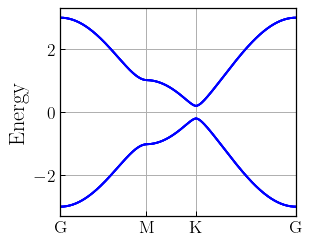

In [66]:
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat, order=1)

h = Hamiltonian(norb=1, nspin=2, nph=2, 
                lat=lat, hops_nn=hops_nn) #now we also turn on particle-hole by nph=2
h.add_mu(0.)
h.add_nnhops(amp=1.0)
h.add_s_wave(0.2) #out-of-plane

kpath, kpath_1d, ticks = lat.find_kpath(n_kpts=300)
bands = Solver(h).get_bands(kpath)
Plotter().plot_bands(bands, kpath_1d, ticks)

#### Projected bands 

* We can also plot projected bands e.g. particle-projected bands for SC

* This shows a combination of electron and holes around E=0, where there is a discontinuity of weight.

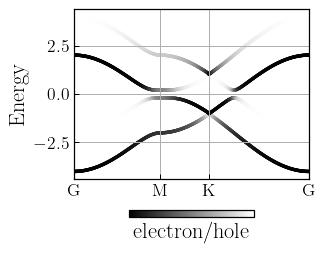

In [ ]:
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat)

h = Hamiltonian(norb=1, nspin=2, nph=2, 
                lat=lat, hops_nn=hops_nn)
h.add_mu(-1.) #notice we set mu=-1
h.add_nnhops(amp=1.0)
h.add_s_wave(0.2) #out-of-plane

kpath, kpath_1d, ticks = lat.find_kpath(n_kpts=300)
bands, w_el = Solver(h).get_particle_proj_bands(kpath)
Plotter().plot_particle_bands(bands, w_el, kpath_1d, ticks)

#### Multiorbital hopping

* For multiorbitals, the hopping element is a matrix 

* We can construct the matrix from Slater-Koster table

* Slater-Koster paramteres can be taken from [$\emph{ab initio}$ results](https://doi.org/10.1103/PhysRevB.82.245412),
which produces accurate electronic bands

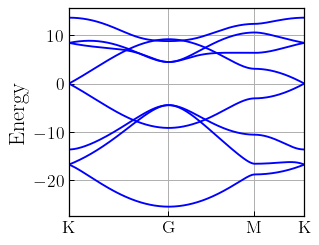

In [97]:
# We take one s and three p orbitals
 
lat = Lattice.honeycomb() #define bulk lattice
hops_nn, _ = Hopping().find_hops(lat)

h = Hamiltonian(norb=4, nspin=1, nph=1, 
                lat=lat, hops_nn=hops_nn) #notice, norb=4

#SK params is a dict
SK_params = {
    'onsite': {'s': 8.37, 'px': 0.0, 'py': 0.0, 'pz': 0.0},
    'Vss': -5.729, 'Vsp': 5.618, 'Vpp_sigma': 6.050, 'Vpp_pi': -3.070
}
hop_matrix_sk = h.sk_table(orb_type='s+p', SK_params=SK_params)
h.add_multiorb_sk(hop_matrix_sk, SK_params)

# We use the path K-G-M-K to reproduce Konschuh et. al.
kpath, kpath_1d, ticks = lat.find_kpath(kpath_labels=['K', 'G', 'M', 'K'],
                                        kpath_frac=[[2/3,1/3,0], [0,0,0], [0.5,0,0], [2/3,1/3,0]], 
                                        n_kpts=300)
bands = Solver(h).get_bands(kpath)
Plotter().plot_bands(bands, kpath_1d, ticks)

Orbital-projection shows Dirac bands near E=0 comes from out-of-plane $p_z$ orbitals

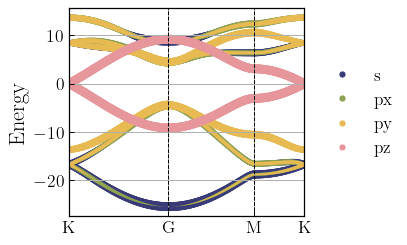

In [96]:
bands, w_orb = Solver(h).get_orb_proj_bands(kpath)
Plotter().plot_orb_bands(bands, w_orb, kpath_1d, ticks, orb_names=['s', 'px', 'py', 'pz'])